# M3: Knowledge Graph Construction

Build a knowledge graph from the ingested course content with:

**Nodes:**
- `concept`: {id, title, difficulty, aliases, definitions}
- `resource`: {type, span, timecodes}
- `example`: worked example snippets

**Edges:**
- `prereq_of`: prerequisite relationships (DAG)
- `explains`: resource → concept
- `exemplifies`: example → concept
- `near_transfer`: concept ↔ concept (related concepts)

## Setup and Imports

In [1]:
!pip install matplotlib scipy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys
sys.path.append('/workspace')

from ingestion.mongo_helper import MongoHelper
import requests
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import scipy
print("Imports successful")

Imports successful


## 1. Initialize Graph and Connect to Data

In [3]:
# Initialize
mongo = MongoHelper()
graph = nx.DiGraph()

# Ollama configuration
OLLAMA_URL = "http://ollama:11434/api/generate"
MODEL = "qwen2.5:7b"

print("Connected to MongoDB")
print(f"Ollama URL: {OLLAMA_URL}")
print(f"Using model: {MODEL}")

Connected to MongoDB
Ollama URL: http://ollama:11434/api/generate
Using model: qwen2.5:7b


## 2. Helper Function: Query Ollama

In [4]:
def query_ollama(prompt: str, temperature: float = 0.3, max_tokens: int = 1000, num_ctx: int = 4096) -> str:
    """Query the local Ollama LLM.

    num_ctx defaults to 4096 -- Ollama's own default is 2048 unless overridden
    here, which is smaller than a single extract_concepts() call actually
    needs: an 8000-char chunk (~2000 tokens) + the fixed prompt wrapper
    (~260 tokens) + num_predict reserved for the response (1000) totals
    ~3260 tokens, already past the 2048 default before any output is
    generated. Confirmed via `docker compose exec ollama ollama show
    qwen2.5:7b --modelfile` returning no PARAMETER num_ctx line. Without
    this override, calls were very likely being silently truncated by
    Ollama, meaning the model was never actually seeing the back half of
    most chunks -- independent of, and in addition to, the max_chunks=30
    per-page truncation issue.
    """
    payload = {
        "model": MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
            "num_ctx": num_ctx
        }
    }
    
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=60)
        if response.status_code == 200:
            return response.json()['response']
        else:
            print(f"Error: Status {response.status_code}")
            return None
    except Exception as e:
        print(f"Error querying Ollama: {e}")
        return None

# Test Ollama
test_response = query_ollama("Say 'Hello, I am ready!' in 5 words or less.")
print(f"Ollama test: {test_response}")

Ollama test: Ready, hello there!


## 3. Extract Concepts from Course Content

In [5]:
import json
from typing import List, Dict


def chunk_text(text: str, chunk_size: int = 8000, overlap: int = 800, max_chunks=30) -> List[str]:
    """
    Split text into overlapping chunks to preserve context.
    
    Args:
        text: Text to chunk
        chunk_size: Maximum characters per chunk (default: 8000 ≈ 1300-1500 words)
        overlap: Characters to overlap between chunks (default: 800 ≈ 10% overlap)
        max_chunks: Maximum number of chunks to prevent explosion (default: 30).
            Pass None for no cap -- used for slide/PDF sources, where a fixed
            cap sized for lecture-page-length content silently truncates full
            textbooks to their first ~14-26% (e.g. RLbook2020.pdf needs ~208
            chunks and mml-book.pdf ~116 at these chunk_size/overlap settings
            -- both were being cut to 30, discarding most of the book).
    
    Returns:
        List of text chunks
    """
    if len(text) <= chunk_size:
        return [text]
    
    chunks = []
    start = 0
    
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk = text[start:end]
        chunks.append(chunk)
        
        if end >= len(text):
            break
            
        start += chunk_size - overlap  # Overlap to preserve context
    
    # Safety check: cap total chunks (skipped entirely if max_chunks is None)
    if max_chunks is not None and len(chunks) > max_chunks:
        print(f"  WARNING: Page has {len(chunks)} chunks (text length: {len(text):,} chars)")
        print(f"  Truncating to {max_chunks} chunks to avoid processing explosion")
        chunks = chunks[:max_chunks]
    
    return chunks


def extract_concepts(text: str, url: str, chunk_id: str = None, 
                     query_ollama_func=None, max_chunks=30) -> List[Dict]:
    """
    Extract AI/ML concepts from text using LLM with chunking support.
    
    Args:
        text: Text to extract concepts from
        url: Source URL for metadata
        chunk_id: Optional identifier for the chunk
        query_ollama_func: Function to query Ollama (must be passed in)
    
    Returns:
        (concepts, examples) tuple. concepts: list of dicts with keys
        title, difficulty, aliases, definition, source_url, chunk_id.
        examples: list of dicts with keys title, illustrates_concept, snippet,
        source_url, chunk_id (usually empty for most chunks).
    """
    
    if query_ollama_func is None:
        raise ValueError("query_ollama_func must be provided")
    
    # Chunk the text for better processing
    chunks = chunk_text(text, chunk_size=8000, overlap=800, max_chunks=max_chunks)
    all_concepts = []
    all_examples = []  # worked examples, each tagged with illustrates_concept
    
    print(f"  Processing {len(chunks)} chunks (total text: {len(text):,} chars)")
    
    for i, chunk in enumerate(chunks):
        current_chunk_id = f"{chunk_id or 'chunk'}_{i+1}" if len(chunks) > 1 else chunk_id
        
        print(f"  Processing chunk {i+1}/{len(chunks)} ({len(chunk):,} chars)")
        
        prompt = f"""You are analyzing AI course material. Extract key AI/ML concepts AND worked examples from this text.

Text:
{chunk}

Extract two things:

1. CONCEPTS (3-5): Look for algorithm names, mathematical concepts and inequalities
   (e.g., Jensen's Inequality), loss functions and bounds (e.g., ELBO, Variational
   Lower Bound), model architectures, and techniques/methods.

2. EXAMPLES (0-2): Worked examples, numeric walkthroughs, or concrete applications
   that DEMONSTRATE one of the concepts above (e.g., a specific PDDL planning
   problem, a numeric backprop calculation, a code snippet solving a specific
   case). Only include an example if the text actually contains one -- most
   chunks won't, and that's fine, return an empty list for those.

Return ONLY a valid JSON object with this exact shape. No explanation, no markdown formatting.

Format:
{{
  "concepts": [
    {{"title": "Gradient Descent", "difficulty": "intermediate", "aliases": ["GD"], "definition": "Optimization algorithm that iteratively updates parameters"}}
  ],
  "examples": [
    {{"title": "Blocksworld PDDL Problem", "illustrates_concept": "Gradient Descent", "snippet": "Short 1-2 sentence description of the worked example"}}
  ]
}}

Rules:
- Return ONLY the JSON object, nothing else
- difficulty must be exactly: "beginner", "intermediate", or "advanced"
- Keep definitions and snippets under 150 characters
- illustrates_concept should match (or closely match) one of the concept titles above, or a concept you'd expect to already exist in the course
- If no concepts found, "concepts": []. If no examples found, "examples": []

JSON object:"""
        
        response = query_ollama_func(prompt, temperature=0.3)
        
        if not response:
            print(f"    ERROR: No response from LLM")
            continue
        
        # DEBUG: Print raw response for first few chunks
        if i < 2:
            print(f"    DEBUG - Raw response: {response[:300]}")
        
        # Extract JSON object (concepts + examples) from response
        try:
            response = response.strip()
            response = response.replace('```json', '').replace('```', '').strip()
            
            start = response.find('{')
            end = response.rfind('}') + 1
            
            if start >= 0 and end > start:
                json_str = response[start:end]
                parsed = json.loads(json_str)
                
                if not isinstance(parsed, dict):
                    print(f"    ERROR: Response is not a JSON object")
                    continue
                
                concepts = parsed.get('concepts', [])
                examples = parsed.get('examples', [])
                
                if not isinstance(concepts, list):
                    concepts = []
                if not isinstance(examples, list):
                    examples = []
                
                for concept in concepts:
                    if not isinstance(concept, dict):
                        continue
                    concept['source_url'] = url
                    concept['chunk_id'] = current_chunk_id
                all_concepts.extend(concepts)
                
                for example in examples:
                    if not isinstance(example, dict):
                        continue
                    example['source_url'] = url
                    example['chunk_id'] = current_chunk_id
                all_examples.extend(examples)
                
                print(f"    Extracted {len(concepts)} concepts, {len(examples)} examples from chunk {i+1}")
            else:
                print(f"    WARNING: No JSON object found in response")
                print(f"    Response was: {response[:200]}")
                
        except json.JSONDecodeError as e:
            print(f"    ERROR: Failed to parse JSON: {e}")
            print(f"    Response was: {response[:300]}")
        except Exception as e:
            print(f"    ERROR: {e}")
    
    # Deduplicate concepts by title (case-insensitive)
    seen_titles = set()
    unique_concepts = []
    
    for concept in all_concepts:
        title_lower = concept.get('title', '').lower()
        if title_lower and title_lower not in seen_titles:
            seen_titles.add(title_lower)
            unique_concepts.append(concept)
    
    if len(all_concepts) != len(unique_concepts):
        print(f"  Deduplicated: {len(all_concepts)} -> {len(unique_concepts)} concepts")
    
    return unique_concepts, all_examples


# Alternative: Token-based chunking (more accurate but requires tiktoken)
def chunk_text_by_tokens(text: str, chunk_size: int = 1500, overlap: int = 150, 
                         max_chunks: int = 30) -> List[str]:
    """
    Split text into overlapping chunks based on approximate token count.
    
    This is more accurate than character-based chunking but still uses a simple approximation.
    For production use, consider using tiktoken or a proper tokenizer.
    
    Args:
        text: Text to chunk
        chunk_size: Maximum tokens per chunk (default: 1500)
        overlap: Tokens to overlap between chunks (default: 150)
        max_chunks: Maximum number of chunks to prevent explosion
    
    Returns:
        List of text chunks
    """
    # Simple approximation: 1 token ≈ 4 characters for English text
    # This is a rough estimate; actual ratio varies
    char_per_token = 4
    
    char_chunk_size = chunk_size * char_per_token
    char_overlap = overlap * char_per_token
    
    return chunk_text(text, char_chunk_size, char_overlap, max_chunks)


# Example usage and testing
if __name__ == "__main__":
    # Test chunking with different text sizes
    test_texts = [
        ("Small text", "This is a small piece of text." * 50),  # ~1500 chars
        ("Medium text", "This is a medium piece of text." * 500),  # ~15000 chars  
        ("Large text", "This is a large piece of text." * 5000),  # ~150000 chars
        ("Huge text", "This is a huge piece of text." * 15000),  # ~450000 chars
    ]
    
    print("=" * 70)
    print("CHUNKING ANALYSIS")
    print("=" * 70)
    
    for name, text in test_texts:
        chunks_old = chunk_text(text, chunk_size=2000, overlap=200)  # Old settings
        chunks_new = chunk_text(text, chunk_size=8000, overlap=800)  # New settings
        
        print(f"\n{name}:")
        print(f"  Text length: {len(text):,} characters")
        print(f"  Old chunking (2000/200): {len(chunks_old)} chunks")
        print(f"  New chunking (8000/800): {len(chunks_new)} chunks")
        print(f"  Reduction: {len(chunks_old) - len(chunks_new)} chunks ({100 - (len(chunks_new)/len(chunks_old)*100):.1f}% reduction)")

CHUNKING ANALYSIS

Small text:
  Text length: 1,500 characters
  Old chunking (2000/200): 1 chunks
  New chunking (8000/800): 1 chunks
  Reduction: 0 chunks (0.0% reduction)

Medium text:
  Text length: 15,500 characters
  Old chunking (2000/200): 9 chunks
  New chunking (8000/800): 3 chunks
  Reduction: 6 chunks (66.7% reduction)
  Truncating to 30 chunks to avoid processing explosion

Large text:
  Text length: 150,000 characters
  Old chunking (2000/200): 30 chunks
  New chunking (8000/800): 21 chunks
  Reduction: 9 chunks (30.0% reduction)
  Truncating to 30 chunks to avoid processing explosion
  Truncating to 30 chunks to avoid processing explosion

Huge text:
  Text length: 435,000 characters
  Old chunking (2000/200): 30 chunks
  New chunking (8000/800): 30 chunks
  Reduction: 0 chunks (0.0% reduction)


## 4. Process Pages and Build Graph

Start with a small sample to test the pipeline.

In [6]:
# Process first 5 pages as a test
NUM_PAGES = 5
pages = list(mongo.db.webpages.find().limit(NUM_PAGES))
print(f"Processing {len(pages)} pages...\n")

concepts_dict = {}  # concept_id -> concept_data
resources_dict = {}  # resource_id -> resource_data
concept_to_resources = defaultdict(list)  # Track which resources explain each concept

for page_num, page in enumerate(pages, 1):
    print(f"[{page_num}/{len(pages)}] {page['title'][:60]}...")
    
    # Extract concepts with chunking (now processes entire document)
    concepts, examples = extract_concepts(
    text=page['content'], 
    url=page['url'],
    chunk_id=f"page_{page_num}",
    query_ollama_func=query_ollama 
    )
    
    if not concepts:
        print(f"  WARNING: No concepts extracted from this page\n")
        continue
    
    for concept in concepts:
        # Generate unique concept ID
        concept_id = concept['title'].lower().replace(' ', '_').replace('-', '_')
        
        # Add or update concept node
        if concept_id not in concepts_dict:
            concepts_dict[concept_id] = {
                'title': concept['title'],
                'difficulty': concept.get('difficulty', 'intermediate'),
                'aliases': concept.get('aliases', []),
                'definition': concept.get('definition', '')
            }
            graph.add_node(concept_id, node_type='concept', **concepts_dict[concept_id])
            print(f"  Added Concept: {concept['title']} ({concept.get('difficulty', 'intermediate')})")
        else:
            # Concept already exists, optionally merge/update definition
            existing_def = concepts_dict[concept_id]['definition']
            new_def = concept.get('definition', '')
            
            # Keep the longer definition (usually more informative)
            if len(new_def) > len(existing_def):
                concepts_dict[concept_id]['definition'] = new_def
                graph.nodes[concept_id]['definition'] = new_def
        
        # Create unique resource ID for this chunk
        chunk_id = concept.get('chunk_id', f"page_{page_num}_chunk_1")
        resource_id = f"resource_{page_num}_{chunk_id}"
        
        # Add resource node with span information
        if resource_id not in resources_dict:
            resources_dict[resource_id] = {
                'type': 'web',
                'url': page['url'],
                'title': page['title'],
                'span': chunk_id,  # M3 requirement: track which chunk/span
                'page_num': page_num
            }
            graph.add_node(resource_id, node_type='resource', **resources_dict[resource_id])
        
        # Add 'explains' edge: resource -> concept
        if not graph.has_edge(resource_id, concept_id):
            graph.add_edge(resource_id, concept_id, relation='explains')
            concept_to_resources[concept_id].append(resource_id)
    
    print()

# Summary statistics
print(f"\n{'='*60}")
print(f"EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"Extracted {len(concepts_dict)} unique concepts")
print(f"Created {len(resources_dict)} resource nodes (with spans)")
print(f"Created {graph.number_of_edges()} edges")
print(f"\nDifficulty distribution:")

# Count concepts by difficulty
difficulty_counts = defaultdict(int)
for concept_data in concepts_dict.values():
    difficulty_counts[concept_data['difficulty']] += 1

for difficulty, count in sorted(difficulty_counts.items()):
    print(f"  {difficulty}: {count} concepts")

print(f"\nTop concepts by resource coverage:")
# Show which concepts are explained by the most resources
top_concepts = sorted(concept_to_resources.items(), 
                     key=lambda x: len(x[1]), 
                     reverse=True)[:5]

for concept_id, resources in top_concepts:
    concept_title = concepts_dict[concept_id]['title']
    print(f"  {concept_title}: {len(resources)} resource chunks")

Processing 5 pages...

[1/5] Home - aegean.ai...
  Processing 1 chunks (total text: 2,050 chars)
  Processing chunk 1/1 (2,050 chars)
    DEBUG - Raw response: {
  "concepts": [],
  "examples": []
}
    Extracted 0 concepts, 0 examples from chunk 1

[2/5] Introduction...
  Processing 2 chunks (total text: 8,124 chars)
  Processing chunk 1/2 (8,000 chars)
    DEBUG - Raw response: {
  "concepts": [
    {"title": "Backpropagation", "difficulty": "intermediate", "aliases": ["BP"], "definition": "Algorithm for computing gradients in neural networks"},
    {"title": "Markov Decision Processes (MDPs)", "difficulty": "advanced", "aliases": [], "definition": "Model used to describe 
    Extracted 4 concepts, 0 examples from chunk 1
  Processing chunk 2/2 (924 chars)
    DEBUG - Raw response: {
  "concepts": [
    {"title": "SARSA", "difficulty": "intermediate", "aliases": [], "definition": "On-policy reinforcement learning algorithm"}
  ],
  "examples": []
}
    Extracted 1 concepts, 0 example

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from IPython.display import display
import os

def visualize_graph(graph, filename='knowledge_graph.png'):
    """Visualize the complete knowledge graph"""
    
    fig, ax = plt.subplots(figsize=(20, 16))
    
    # Separate nodes by type
    concept_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']
    resource_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'resource']
    
    # Use spring layout
    pos = nx.spring_layout(graph, k=2, iterations=50, seed=42)
    
    # Draw concept nodes
    nx.draw_networkx_nodes(graph, pos, 
                          nodelist=concept_nodes,
                          node_color='lightblue',
                          node_size=3000,
                          alpha=0.9,
                          node_shape='o',
                          ax=ax)
    
    # Draw resource nodes
    nx.draw_networkx_nodes(graph, pos,
                          nodelist=resource_nodes,
                          node_color='lightgreen',
                          node_size=1500,
                          alpha=0.7,
                          node_shape='s',
                          ax=ax)
    
    # Draw edges by type with different colors
    prereq_edges_list = [(u, v) for u, v, d in graph.edges(data=True) if d.get('relation') == 'prereq_of']
    explains_edges_list = [(u, v) for u, v, d in graph.edges(data=True) if d.get('relation') == 'explains']
    
    # Draw prerequisite edges (blue arrows)
    nx.draw_networkx_edges(graph, pos,
                          edgelist=prereq_edges_list,
                          edge_color='blue',
                          arrows=True,
                          arrowsize=20,
                          width=2,
                          alpha=0.6,
                          arrowstyle='->',
                          ax=ax)
    
    # Draw explains edges (green arrows)
    nx.draw_networkx_edges(graph, pos,
                          edgelist=explains_edges_list,
                          edge_color='green',
                          arrows=True,
                          arrowsize=15,
                          width=1,
                          alpha=0.4,
                          arrowstyle='->',
                          ax=ax)
    
    # Draw labels - use shortened titles for concepts
    labels = {}
    for n, d in graph.nodes(data=True):
        if d.get('node_type') == 'concept':
            title = d.get('title', n)
            # Shorten long titles
            if len(title) > 25:
                title = title[:22] + '...'
            labels[n] = title
        else:
            labels[n] = ''  # Don't label resource nodes (too cluttered)
    
    nx.draw_networkx_labels(graph, pos, labels, font_size=8, font_weight='bold', ax=ax)
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
               markersize=15, label='Concept Node'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgreen', 
               markersize=12, label='Resource Node'),
        Line2D([0], [0], color='blue', linewidth=2, label='prereq_of'),
        Line2D([0], [0], color='green', linewidth=1, label='explains')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
    
    ax.set_title('Knowledge Graph: Concepts and Resources', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    # Save to workspace
    output_path = f'/workspace/{filename}'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {output_path}")
    
    # Display in notebook
    plt.show()


def visualize_concept_hierarchy(graph, filename='concept_hierarchy.png'):
    """Visualize just the concept prerequisite DAG"""
    
    # Extract only concepts and prerequisites
    concept_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']
    prereq_edges = [(u, v) for u, v, d in graph.edges(data=True) 
                    if d.get('relation') == 'prereq_of' and u in concept_nodes and v in concept_nodes]
    
    # Create subgraph
    concept_graph = nx.DiGraph()
    concept_graph.add_nodes_from(concept_nodes)
    concept_graph.add_edges_from(prereq_edges)
    
    # Add node attributes
    for n in concept_nodes:
        concept_graph.nodes[n]['title'] = graph.nodes[n].get('title', n)
        concept_graph.nodes[n]['difficulty'] = graph.nodes[n].get('difficulty', 'intermediate')
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Use spring layout
    pos = nx.spring_layout(concept_graph, k=3, iterations=100, seed=42)
    
    # Color by difficulty
    color_map = {
        'beginner': 'lightgreen',
        'intermediate': 'lightblue',
        'advanced': 'salmon'
    }
    
    node_colors = [color_map.get(concept_graph.nodes[n].get('difficulty', 'intermediate'), 'lightgray') 
                   for n in concept_graph.nodes()]
    
    # Draw nodes
    nx.draw_networkx_nodes(concept_graph, pos,
                          node_color=node_colors,
                          node_size=3500,
                          alpha=0.9,
                          ax=ax)
    
    # Draw edges
    nx.draw_networkx_edges(concept_graph, pos,
                          edge_color='gray',
                          arrows=True,
                          arrowsize=20,
                          width=2,
                          alpha=0.6,
                          arrowstyle='->',
                          ax=ax)
    
    # Labels
    labels = {n: concept_graph.nodes[n].get('title', n) for n in concept_graph.nodes()}
    nx.draw_networkx_labels(concept_graph, pos, labels, font_size=9, font_weight='bold', ax=ax)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightgreen', label='Beginner'),
        Patch(facecolor='lightblue', label='Intermediate'),
        Patch(facecolor='salmon', label='Advanced')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
    
    ax.set_title('Concept Prerequisite Hierarchy (DAG)', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    # Save to workspace
    output_path = f'/workspace/{filename}'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {output_path}")
    
    # Display in notebook
    plt.show()


## Attempt to extract all pages

In [8]:
# Process ALL pages, slides, and videos from MongoDB -- the three ingestion
# sources M2 now populates, matching the Erica spec's Resource schema
# (type in [pdf, slide, video, web]). Previously this cell only ever read
# mongo.db.webpages, meaning every slide (including RLbook2020.pdf and
# mml-book.pdf, your two largest sources) and every video transcript was
# sitting in MongoDB completely unused by concept extraction.
print("="*60)
print("PROCESSING ALL SOURCES (webpages + slides + videos)")
print("="*60)

webpages = list(mongo.db.webpages.find())
slides = list(mongo.db.slides.find())
videos = list(mongo.db.videos.find()) if 'videos' in mongo.db.list_collection_names() else []

print(f"Found {len(webpages)} webpages, {len(slides)} slides, {len(videos)} videos\n")

total_sources = len(webpages) + len(slides) + len(videos)
print(f"This will process all {total_sources} sources.")
print("Estimated time: ~{} minutes (depending on LLM speed)".format(total_sources * 2))
print("\nProcessing...")
print("="*60 + "\n")

concepts_dict = {}       # concept_id -> concept_data
resources_dict = {}      # resource_id -> resource_data
examples_dict = {}       # example_id -> example_data
concept_to_resources = defaultdict(list)

def _slide_type(url: str) -> str:
    return 'pdf' if url.lower().endswith('.pdf') else 'slide'

def _process_source(source_num, title, url, content, source_type, resource_type, span_label):
    """Shared per-source processing: extract concepts + examples, add nodes
    and edges. source_type is 'webpage'/'slide'/'video' (for logging only);
    resource_type is what actually gets stored on the Resource node, per
    the spec's type in [pdf, slide, video, web].

    max_chunks is uncapped for slides -- webpages stay capped at 30 (the
    default), which is fine for lecture-page-length content, but the same
    cap silently truncated full textbook PDFs (RLbook2020.pdf, mml-book.pdf)
    to their first ~14-26%. Not applied to webpages/videos: web pages never
    come close to 30 chunks in practice, and video transcripts are bounded
    by lecture length rather than book length."""
    print(f"[{source_num}] ({source_type}) {title[:60]}...")

    source_max_chunks = None if source_type == 'slide' else 30

    concepts, examples = extract_concepts(
        text=content,
        url=url,
        chunk_id=f"{source_type}_{source_num}",
        query_ollama_func=query_ollama,
        max_chunks=source_max_chunks
    )

    if not concepts:
        print(f"  WARNING: No concepts extracted from this source\n")
        return

    resource_id = f"resource_{source_type}_{source_num}"
    if resource_id not in resources_dict:
        resources_dict[resource_id] = {
            'type': resource_type,
            'url': url,
            'title': title,
            'span': span_label,
        }
        graph.add_node(resource_id, node_type='resource', **resources_dict[resource_id])

    for concept in concepts:
        concept_id = concept['title'].lower().replace(' ', '_').replace('-', '_')

        if concept_id not in concepts_dict:
            concepts_dict[concept_id] = {
                'title': concept['title'],
                'difficulty': concept.get('difficulty', 'intermediate'),
                'aliases': concept.get('aliases', []),
                'definition': concept.get('definition', '')
            }
            graph.add_node(concept_id, node_type='concept', **concepts_dict[concept_id])
            print(f"  Added Concept: {concept['title']} ({concept.get('difficulty', 'intermediate')})")
        else:
            existing_def = concepts_dict[concept_id]['definition']
            new_def = concept.get('definition', '')
            if len(new_def) > len(existing_def):
                concepts_dict[concept_id]['definition'] = new_def
                graph.nodes[concept_id]['definition'] = new_def

        if not graph.has_edge(resource_id, concept_id):
            graph.add_edge(resource_id, concept_id, relation='explains')
            concept_to_resources[concept_id].append(resource_id)

    # Example nodes + exemplifies edges. illustrates_concept is matched
    # against concepts extracted in THIS SAME batch first (cheap, exact),
    # falling back to a token-overlap check against the whole concepts_dict
    # so an example can still attach even if its concept was defined on an
    # earlier page.
    for example in examples:
        illustrates = (example.get('illustrates_concept') or '').lower().replace(' ', '_').replace('-', '_')
        target_concept_id = None
        if illustrates in concepts_dict:
            target_concept_id = illustrates
        else:
            illustrates_tokens = set(illustrates.split('_'))
            for cid in concepts_dict:
                if illustrates_tokens & set(cid.split('_')):
                    target_concept_id = cid
                    break
        if not target_concept_id:
            continue  # can't anchor this example to a known concept, skip it

        example_id = f"example_{source_type}_{source_num}_{len(examples_dict)}"
        examples_dict[example_id] = {
            'title': example.get('title', 'Worked Example'),
            'snippet': example.get('snippet', ''),
            'url': url,
        }
        graph.add_node(example_id, node_type='example', **examples_dict[example_id])
        graph.add_edge(example_id, target_concept_id, relation='exemplifies')
        print(f"  Added Example: {example.get('title', 'Worked Example')} -> exemplifies -> {target_concept_id}")

    print()


source_num = 0

for page in webpages:
    source_num += 1
    _process_source(source_num, page['title'], page['url'], page['content'],
                     'webpage', 'web', f"page_{source_num}")
    if source_num % 10 == 0:
        print(f"\nProgress: {source_num}/{total_sources} sources processed")
        print(f"Current stats: {len(concepts_dict)} concepts, {len(resources_dict)} resources, {len(examples_dict)} examples\n")

for slide in slides:
    source_num += 1
    _process_source(source_num, slide.get('filename', slide['url']), slide['url'], slide['content'],
                     'slide', _slide_type(slide['url']), f"page_{source_num}")
    if source_num % 10 == 0:
        print(f"\nProgress: {source_num}/{total_sources} sources processed")
        print(f"Current stats: {len(concepts_dict)} concepts, {len(resources_dict)} resources, {len(examples_dict)} examples\n")

for video in videos:
    source_num += 1
    # Span for a video resource is a timecode, not a page number -- use the
    # transcript's first segment start time as a representative timecode.
    segments = video.get('segments', [])
    start_seconds = int(segments[0]['start']) if segments else 0
    timecode = f"{start_seconds // 60:02d}:{start_seconds % 60:02d}"
    _process_source(source_num, video.get('video_id', video['url']), video['url'], video['content'],
                     'video', 'video', timecode)

print(f"\n{'='*60}")
print(f"EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"Extracted {len(concepts_dict)} unique concepts")
print(f"Created {len(resources_dict)} resource nodes (webpages + slides + videos, with spans/timecodes)")
print(f"Created {len(examples_dict)} example nodes (exemplifies edges)")
print(f"Created {graph.number_of_edges()} edges total")
print(f"\nDifficulty distribution:")

difficulty_counts = defaultdict(int)
for concept_data in concepts_dict.values():
    difficulty_counts[concept_data['difficulty']] += 1

for difficulty, count in sorted(difficulty_counts.items()):
    print(f"  {difficulty}: {count} concepts")

print(f"\nTop concepts by resource coverage:")
top_concepts = sorted(concept_to_resources.items(),
                     key=lambda x: len(x[1]),
                     reverse=True)[:10]

for concept_id, resources in top_concepts:
    concept_title = concepts_dict[concept_id]['title']
    print(f"  {concept_title}: {len(resources)} resource chunks")


PROCESSING ALL SOURCES (webpages + slides + videos)
Found 144 webpages, 22 slides, 53 videos

This will process all 219 sources.
Estimated time: ~438 minutes (depending on LLM speed)

Processing...

[1] (webpage) Home - aegean.ai...
  Processing 1 chunks (total text: 2,050 chars)
  Processing chunk 1/1 (2,050 chars)
    DEBUG - Raw response: {
  "concepts": [],
  "examples": []
}
    Extracted 0 concepts, 0 examples from chunk 1

[2] (webpage) Introduction...
  Processing 2 chunks (total text: 8,124 chars)
  Processing chunk 1/2 (8,000 chars)
    DEBUG - Raw response: {
  "concepts": [
    {"title": "Backpropagation", "difficulty": "intermediate", "aliases": ["BP"], "definition": "Algorithm for computing gradients in neural networks"},
    {"title": "Batch Normalization", "difficulty": "intermediate", "aliases": [], "definition": "Normalization technique to stabi
    Extracted 4 concepts, 0 examples from chunk 1
  Processing chunk 2/2 (924 chars)
    DEBUG - Raw response: {
  "concepts

In [9]:
# Print all extracted concepts
print(f"\n{'='*60}")
print(f"ALL EXTRACTED CONCEPTS")
print(f"{'='*60}")
print(f"Total: {len(concepts_dict)} concepts\n")

# Sort concepts alphabetically by title
sorted_concepts = sorted(concepts_dict.items(), key=lambda x: x[1]['title'])

for idx, (concept_id, concept_data) in enumerate(sorted_concepts, 1):
    print(f"{idx:3d}. {concept_data['title']}")
    print(f"     ID: {concept_id}")
    print(f"     Difficulty: {concept_data['difficulty']}")
    
    if concept_data.get('aliases'):
        print(f"     Aliases: {', '.join(concept_data['aliases'])}")
    
    # Show definition preview (first 100 chars)
    definition = concept_data.get('definition', '')
    if definition:
        definition_preview = definition[:100] + "..." if len(definition) > 100 else definition
        print(f"     Definition: {definition_preview}")
    
    # Show how many resources explain this concept
    num_resources = len(concept_to_resources.get(concept_id, []))
    print(f"     Explained by: {num_resources} resource(s)")
    print()

# Optional: Group by difficulty level
print(f"\n{'='*60}")
print(f"CONCEPTS GROUPED BY DIFFICULTY")
print(f"{'='*60}")

for difficulty in ['beginner', 'intermediate', 'advanced']:
    concepts_at_level = [(cid, cdata) for cid, cdata in concepts_dict.items() 
                         if cdata['difficulty'] == difficulty]
    
    if concepts_at_level:
        print(f"\n{difficulty.upper()} ({len(concepts_at_level)} concepts):")
        for concept_id, concept_data in sorted(concepts_at_level, key=lambda x: x[1]['title']):
            print(f"  - {concept_data['title']}")


ALL EXTRACTED CONCEPTS
Total: 1111 concepts

  1. -Greedy Policies
     ID: _greedy_policies
     Difficulty: intermediate
     Aliases: ε-greedy policies
     Definition: Policies that choose actions greedily most of the time, but with probability ε select an action at r...
     Explained by: 1 resource(s)

  2. -greedy Action Selection
     ID: _greedy_action_selection
     Difficulty: beginner
     Aliases: ε-greedy
     Definition: An exploration strategy where with probability (1-ε) the action with the highest estimated value is ...
     Explained by: 1 resource(s)

  3. -greedy Method
     ID: _greedy_method
     Difficulty: intermediate
     Aliases: ε-greedy
     Definition: A strategy that balances exploration and exploitation by choosing a random action with probability ε
     Explained by: 1 resource(s)

  4. -greedy Policy
     ID: _greedy_policy
     Difficulty: beginner
     Definition: Policy that selects the greedy action most of the time and a random action some of th

Generating visualizations...

1. Full Knowledge Graph (Concepts + Resources):
Saved to /workspace/knowledge_graph_full.png


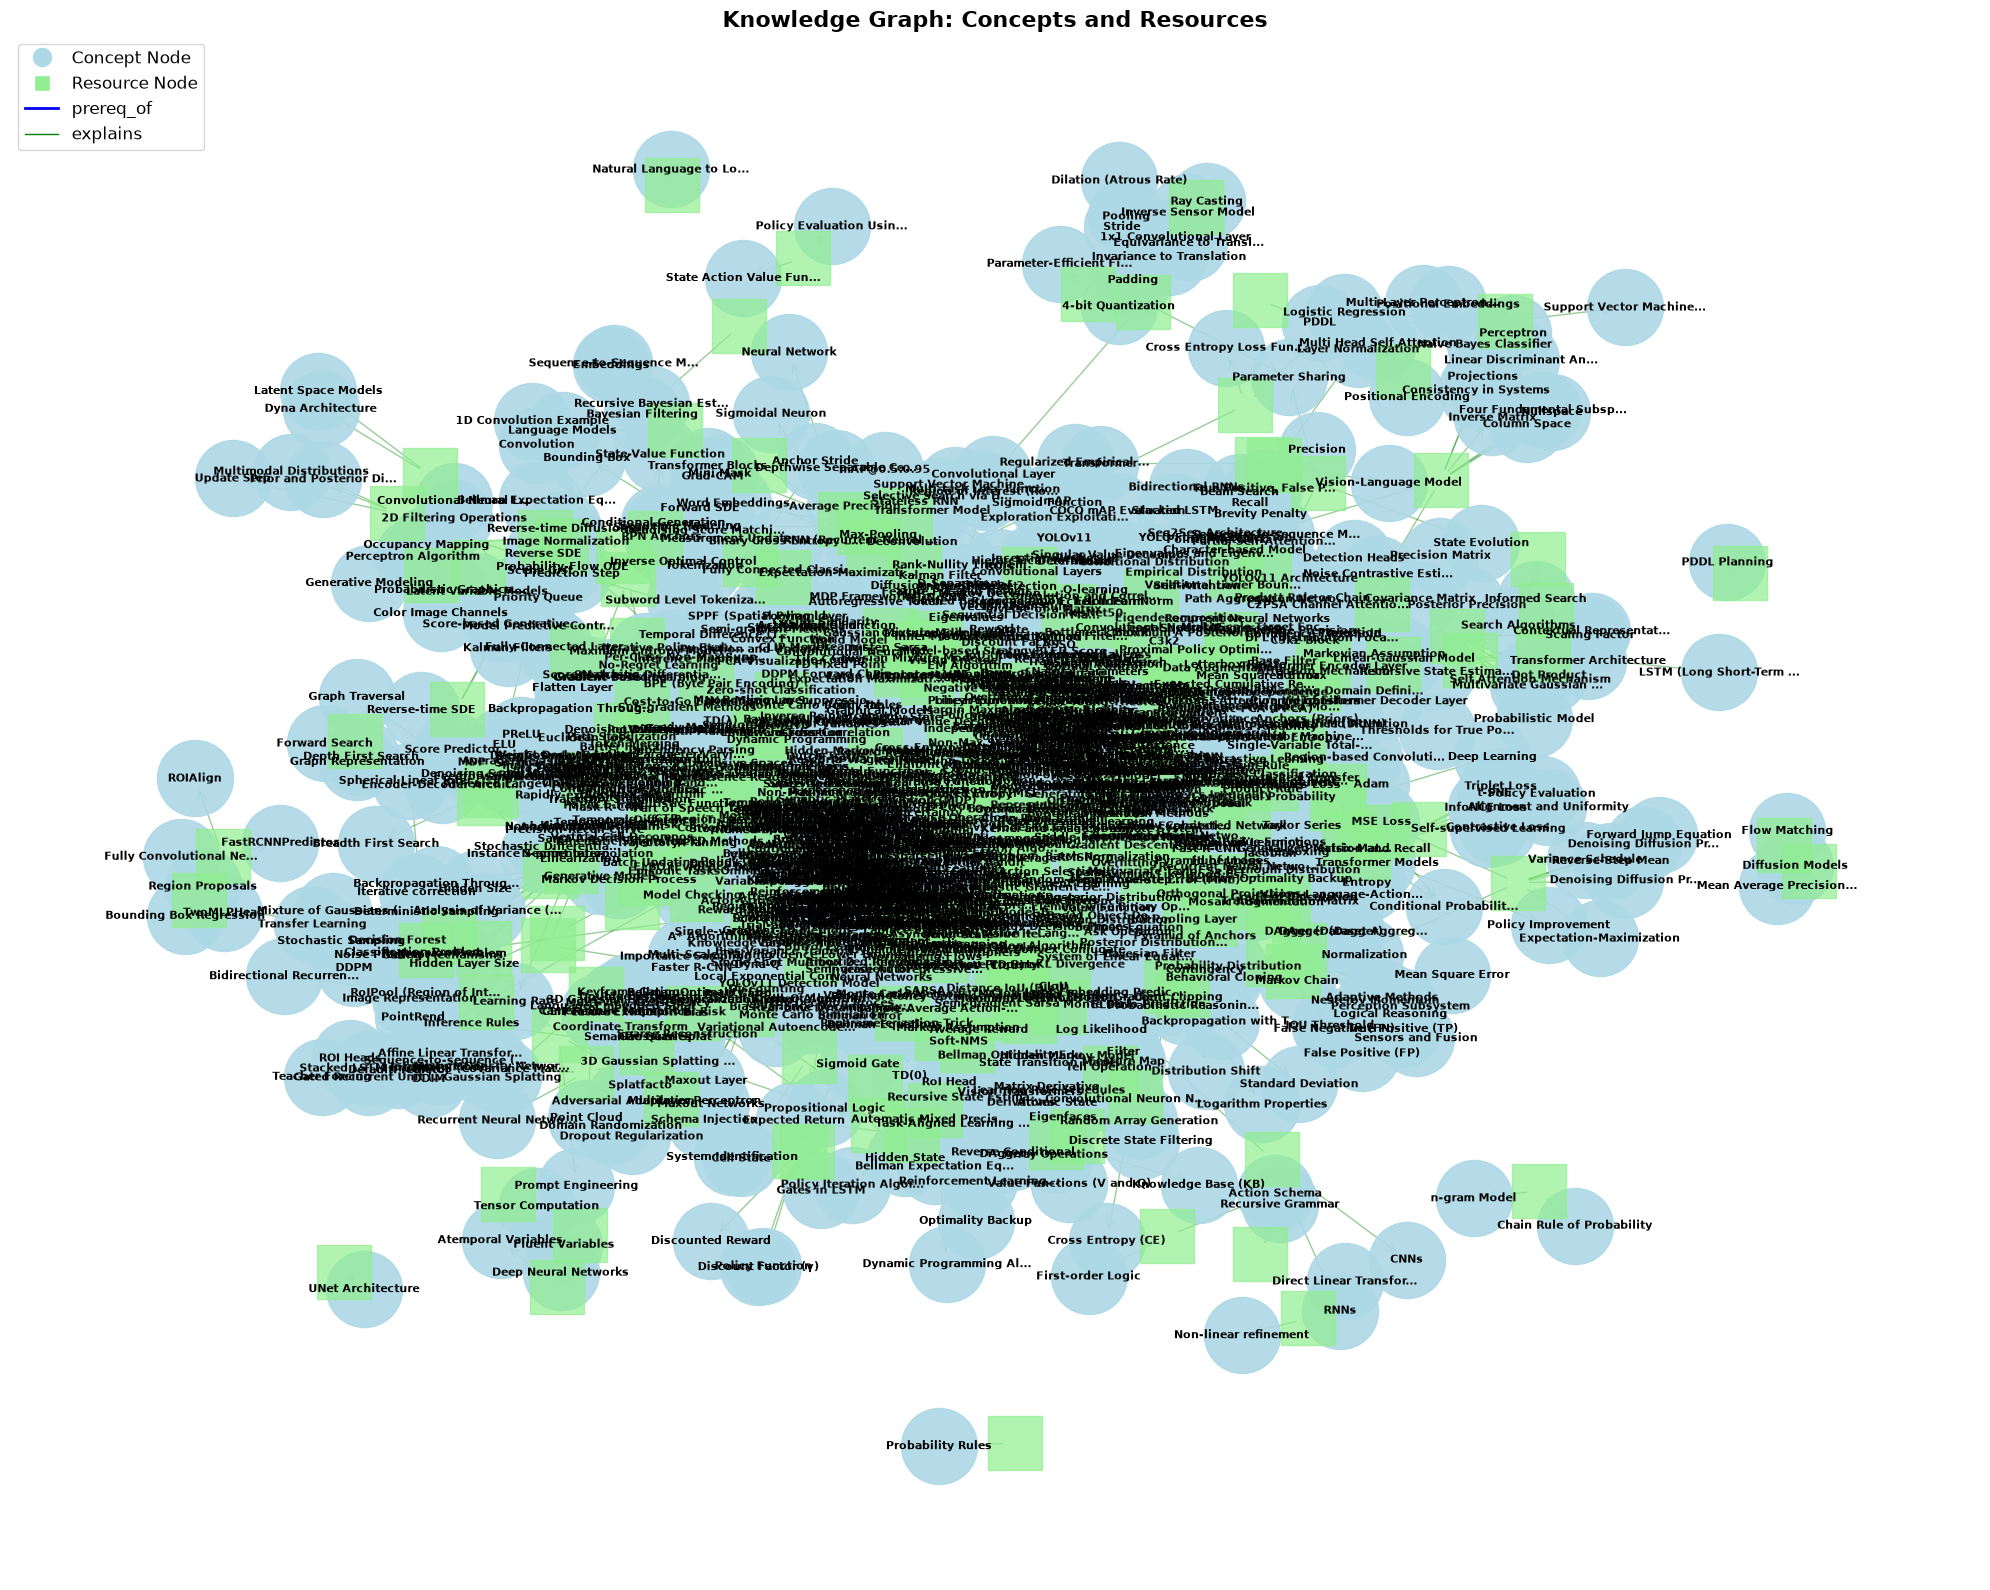


2. Concept Prerequisite Hierarchy:
Saved to /workspace/concept_prerequisite_dag.png


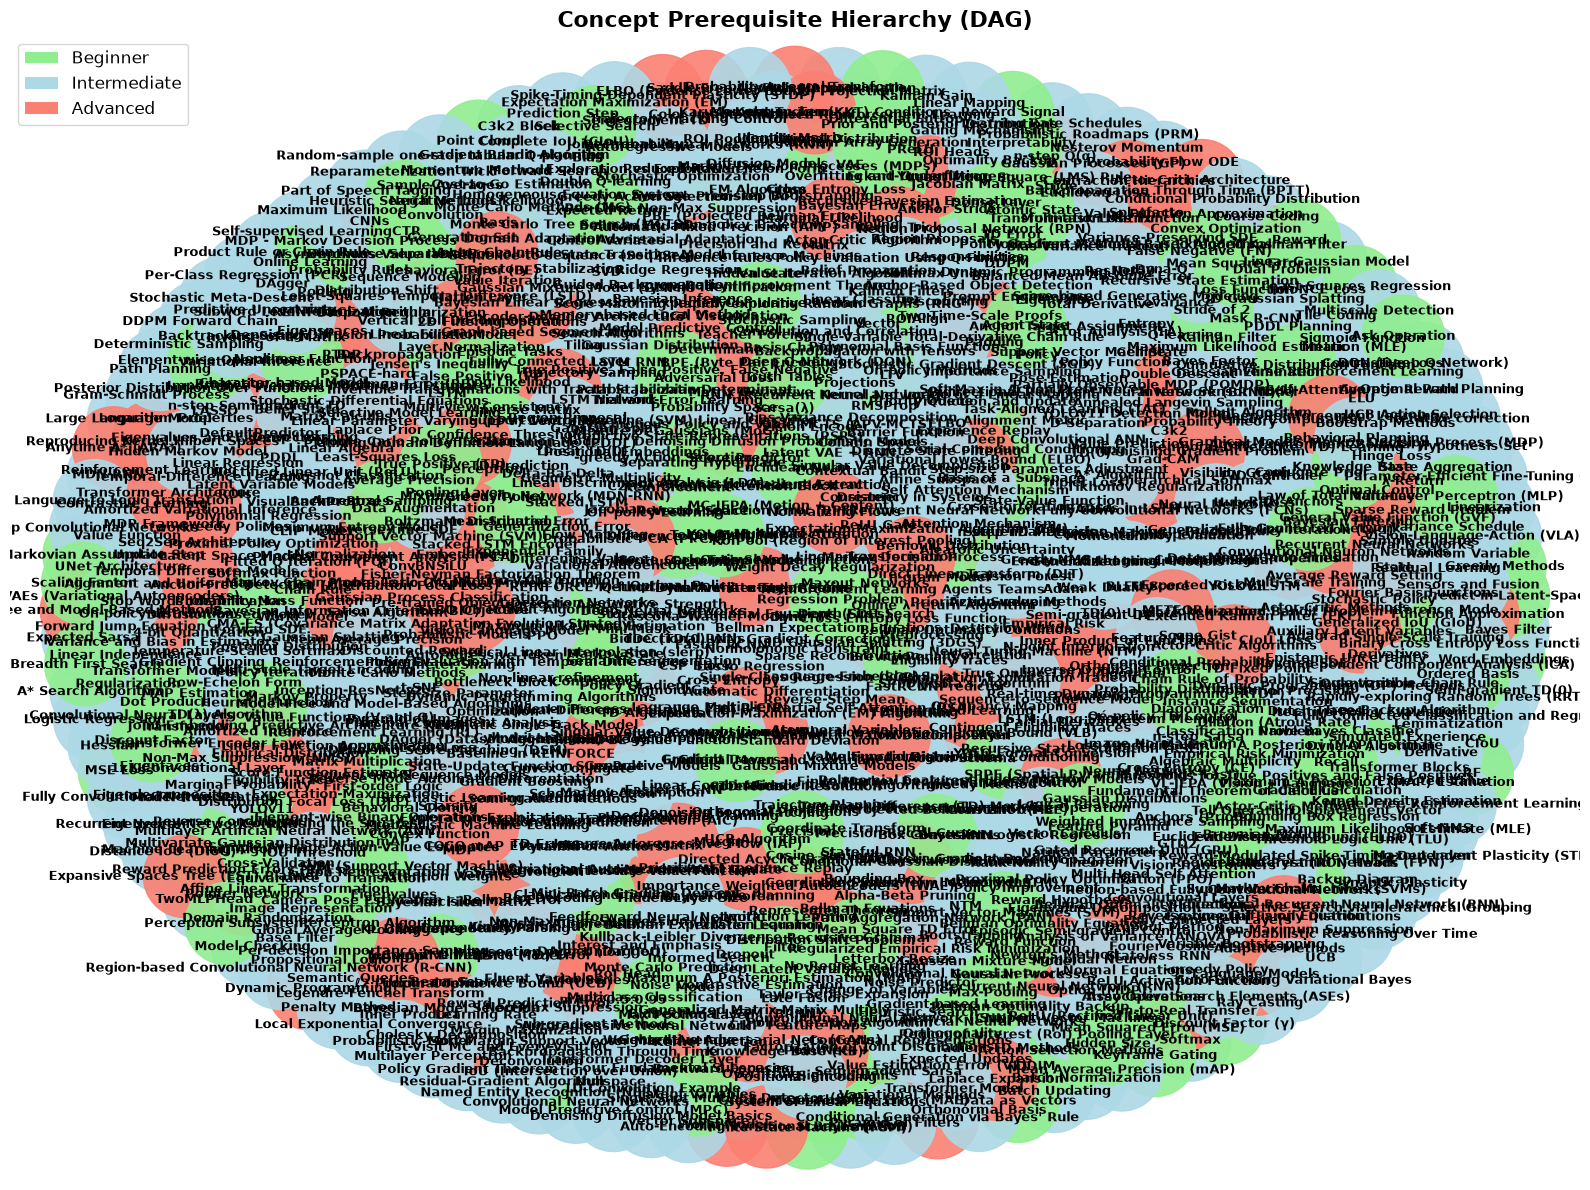


Visualization complete!


In [10]:
# Generate both visualizations
print("Generating visualizations...")
print("="*60)
print("\n1. Full Knowledge Graph (Concepts + Resources):")
visualize_graph(graph, 'knowledge_graph_full.png')

print("\n2. Concept Prerequisite Hierarchy:")
visualize_concept_hierarchy(graph, 'concept_prerequisite_dag.png')

print("\n" + "="*60)
print("Visualization complete!")

## 5. Add Prerequisite Relationships


In [ ]:
def detect_prerequisite(concept1_id: str, concept2_id: str) -> bool:
    """Use LLM to determine if concept1 is a prerequisite for concept2"""
    
    concept1_data = graph.nodes[concept1_id]
    concept2_data = graph.nodes[concept2_id]
    
    concept1_title = concept1_data.get('title', concept1_id)
    concept2_title = concept2_data.get('title', concept2_id)
    
    prompt = f"""You are an AI education expert. Determine if one concept is a prerequisite for another.

Concept A: {concept1_title}
Definition: {concept1_data.get('definition', 'N/A')}

Concept B: {concept2_title}
Definition: {concept2_data.get('definition', 'N/A')}

Question: Must a student understand "{concept1_title}" BEFORE learning "{concept2_title}"?

Answer with ONLY one word: "yes" or "no"
"""
    
    response = query_ollama(prompt, temperature=0.1)
    
    if response and 'yes' in response.lower()[:20]:
        return True
    return False


# --- Candidate pair generation ---------------------------------------------
# Checking ALL possible concept pairs is O(n^2) and infeasible at this
# corpus's scale. Instead of a fixed MAX_CHECKS cap in insertion order
# (which biases coverage toward whichever pages happened to load first),
# generate a justified candidate set: concepts that co-occur on the same
# resource, or whose source pages share a course-module URL prefix.

from urllib.parse import urlparse
from collections import defaultdict

def path_prefix(url: str, depth: int = 4) -> str:
    path = urlparse(url).path.strip('/').split('/')
    return '/'.join(path[:depth])

def build_candidate_pairs(graph, module_depth: int = 4):
    concept_urls = defaultdict(set)
    for u, v, d in graph.edges(data=True):
        if d.get('relation') == 'explains':
            concept_urls[v].add(graph.nodes[u].get('url', ''))

    resource_to_concepts = defaultdict(set)
    for u, v, d in graph.edges(data=True):
        if d.get('relation') == 'explains':
            resource_to_concepts[u].add(v)

    pairs = set()
    for concs in resource_to_concepts.values():
        concs = list(concs)
        for i in range(len(concs)):
            for j in range(i + 1, len(concs)):
                pairs.add(tuple(sorted([concs[i], concs[j]])))

    module_to_concepts = defaultdict(set)
    for c, urls in concept_urls.items():
        for u in urls:
            module_to_concepts[path_prefix(u, module_depth)].add(c)

    for concs in module_to_concepts.values():
        concs = list(concs)
        for i in range(len(concs)):
            for j in range(i + 1, len(concs)):
                pairs.add(tuple(sorted([concs[i], concs[j]])))

    return pairs


print("Building prerequisite relationships using LLM...\n")

concept_list = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']
print(f"Found {len(concept_list)} concepts")

def _has_prereq_edge(graph, a, b):
    return ((graph.has_edge(a, b) and graph[a][b].get('relation') == 'prereq_of') or
            (graph.has_edge(b, a) and graph[b][a].get('relation') == 'prereq_of'))

candidate_pairs = build_candidate_pairs(graph, module_depth=4)
# Only skip pairs that already have a prereq_of edge specifically -- NOT any
# edge. If this cell gets re-run after the canonicalization/near_transfer
# cell has already added near_transfer edges to most candidate pairs (easy
# to do when iterating out of strict top-to-bottom order), a plain
# graph.has_edge() check treats "already has a near_transfer edge" as
# "already handled" and skips the prereq check almost entirely -- which is
# what silently produced only 3 prereq_of edges on a graph this size.
candidate_pairs = [(c1, c2) for c1, c2 in candidate_pairs
                   if not _has_prereq_edge(graph, c1, c2)]
print(f"Candidate pairs (co-occurrence + same-module): {len(candidate_pairs):,}")

MAX_CHECKS = 3000
if len(candidate_pairs) > MAX_CHECKS:
    print(f"  NOTE: {len(candidate_pairs) - MAX_CHECKS:,} lowest-priority candidate pairs skipped (MAX_CHECKS={MAX_CHECKS})")
    candidate_pairs = candidate_pairs[:MAX_CHECKS]

prereq_count = 0
total_checks = 0
rejected_prereq_pairs = []  # kept for near_transfer edge generation later

for c1, c2 in candidate_pairs:
    total_checks += 1
    c1_title = graph.nodes[c1].get('title', c1)
    c2_title = graph.nodes[c2].get('title', c2)

    if total_checks % 50 == 0 or total_checks == 1:
        print(f"[{total_checks}/{len(candidate_pairs)}] Checking: {c1_title[:30]} vs {c2_title[:30]}")

    if detect_prerequisite(c1, c2):
        graph.add_edge(c1, c2, relation='prereq_of')
        prereq_count += 1
        print(f"  PREREQ: {c1_title} -> {c2_title}")
    elif detect_prerequisite(c2, c1):
        graph.add_edge(c2, c1, relation='prereq_of')
        prereq_count += 1
        print(f"  PREREQ: {c2_title} -> {c1_title}")
    else:
        # Related enough to have been a candidate, but no prerequisite
        # relationship either direction -- good near_transfer candidate
        # (siblings/related concepts within the same module).
        rejected_prereq_pairs.append((c1, c2))

print(f"\n{'='*60}")
print(f"PREREQUISITE SUMMARY")
print(f"{'='*60}")
print(f"Added {prereq_count} prerequisite relationships")
print(f"Checked {total_checks} candidate pairs (out of {len(concept_list) * (len(concept_list) - 1) // 2:,} theoretically possible)")
print(f"{len(rejected_prereq_pairs)} pairs kept as near_transfer candidates (related, not prerequisite)")


Building prerequisite relationships using LLM...

Found 1112 concepts
Candidate pairs (co-occurrence + same-module): 61,208
  NOTE: 58,208 lowest-priority candidate pairs skipped (MAX_CHECKS=3000)
[1/3000] Checking: RMSProp vs UCB Algorithm
  PREREQ: Euclidean Norm -> Margin Maximization
  PREREQ: Action-value Methods -> Exploration vs Exploitation
  PREREQ: Belief State -> n-step Bootstrapping
  PREREQ: Basis -> Eckart-Young Theorem
  PREREQ: Function Approximation -> Mean Square TD Error
  PREREQ: Markov Decision Processes (MDPs) -> Policy Evaluation with Temporal Differences
  PREREQ: Belief State -> Actor-Critic Architecture
  PREREQ: Greedy Action Selection -> Semi-gradient DP
  PREREQ: Machine Learning Algorithm -> Bayesian Logistic Regression
  PREREQ: First-Visit MC and Every-Visit MC -> Monte Carlo Policy Iteration
  PREREQ: Average Reward -> REINFORCE Algorithm
[50/3000] Checking: Box Constraints vs Linear Independence
  PREREQ: Linear Algebra -> Gram-Schmidt Process
  PREREQ

In [ ]:
# Validate the prerequisite DAG
def validate_dag(graph):
    """Check if prerequisite edges form a valid DAG (no cycles)"""
    import networkx as nx
    
    # Create subgraph with only prereq edges
    prereq_edges = [(u, v) for u, v, data in graph.edges(data=True) 
                    if data.get('relation') == 'prereq_of']
    
    prereq_graph = nx.DiGraph()
    prereq_graph.add_edges_from(prereq_edges)
    
    # Check for cycles
    try:
        cycles = list(nx.simple_cycles(prereq_graph))
        if cycles:
            print(f"ERROR: Found {len(cycles)} cycles in prerequisite graph!")
            print("\nCycles detected:")
            for i, cycle in enumerate(cycles[:5], 1):  # Show first 5
                cycle_names = [graph.nodes[n].get('title', n) for n in cycle]
                print(f"  {i}. {' -> '.join(cycle_names)} -> {cycle_names[0]}")
            return False
        else:
            print("VALID: No cycles detected in prerequisite graph")
            return True
    except:
        print("ERROR: Could not validate DAG")
        return False


def get_prerequisite_stats(graph):
    """Analyze prerequisite relationships"""
    prereq_edges = [(u, v) for u, v, data in graph.edges(data=True) 
                    if data.get('relation') == 'prereq_of']
    
    # Count incoming and outgoing prereqs
    incoming = defaultdict(int)
    outgoing = defaultdict(int)
    
    for u, v in prereq_edges:
        outgoing[u] += 1  # u is a prereq for something
        incoming[v] += 1  # v has u as a prereq
    
    print("\nPrerequisite Statistics:")
    print("="*60)
    
    print("\nConcepts with most prerequisites (hardest to learn):")
    top_incoming = sorted(incoming.items(), key=lambda x: x[1], reverse=True)[:5]
    for concept_id, count in top_incoming:
        title = graph.nodes[concept_id].get('title', concept_id)
        print(f"  {title}: {count} prerequisites")
    
    print("\nConcepts that are prerequisites for most others (foundational):")
    top_outgoing = sorted(outgoing.items(), key=lambda x: x[1], reverse=True)[:5]
    for concept_id, count in top_outgoing:
        title = graph.nodes[concept_id].get('title', concept_id)
        print(f"  {title}: {count} concepts depend on it")
    
    print("\nRoot concepts (no prerequisites):")
    concept_nodes = [n for n, d in graph.nodes(data=True) 
                     if d.get('node_type') == 'concept']
    roots = [n for n in concept_nodes if incoming[n] == 0]
    for concept_id in roots[:10]:
        title = graph.nodes[concept_id].get('title', concept_id)
        print(f"  - {title}")


# Run validation
print("\n" + "="*60)
print("VALIDATING PREREQUISITE DAG")
print("="*60)

is_valid = validate_dag(graph)
get_prerequisite_stats(graph)

if not is_valid:
    print("\nWARNING: Graph contains cycles and is not a valid DAG!")
    print("This violates M3 requirements. Consider:")
    print("1. Using more selective prerequisite detection")
    print("2. Breaking cycles by removing weakest edges")
    print("3. Using transitive reduction to simplify")

In [ ]:
def remove_cycles(graph):
    """Remove edges to break cycles in prerequisite graph"""
    import networkx as nx
    
    prereq_edges = [(u, v) for u, v, data in graph.edges(data=True) 
                    if data.get('relation') == 'prereq_of']
    
    prereq_graph = nx.DiGraph()
    prereq_graph.add_edges_from(prereq_edges)
    
    # Find and break cycles
    while True:
        try:
            cycle = nx.find_cycle(prereq_graph)
            # Remove the last edge in the cycle
            u, v = cycle[-1][0], cycle[-1][1]
            prereq_graph.remove_edge(u, v)
            graph.remove_edge(u, v)
            
            u_title = graph.nodes[u].get('title', u)
            v_title = graph.nodes[v].get('title', v)
            print(f"  Removed edge: {u_title} -> {v_title} (breaks cycle)")
        except nx.NetworkXNoCycle:
            break
    
    print("\nAll cycles removed. Graph is now a valid DAG.")


# If cycles were found:
if not is_valid:
    print("\nRemoving cycles...")
    remove_cycles(graph)
    
    # Verify again
    print("\nRe-validating...")
    validate_dag(graph)

## Visualization of the graph

In [ ]:
# Generate both visualizations
print("Generating visualizations...")
print("="*60)
print("\n1. Full Knowledge Graph (Concepts + Resources):")
visualize_graph(graph, 'knowledge_graph_full.png')

print("\n2. Concept Prerequisite Hierarchy:")
visualize_concept_hierarchy(graph, 'concept_prerequisite_dag.png')

print("\n" + "="*60)
print("Visualization complete!")

## 5b. Concept Canonicalization + near_transfer Edges

Per-page extraction produces near-duplicate concept nodes for the same idea
(e.g. `PPO` vs `Proximal Policy Optimization (PPO)`), since node identity was
decided by exact-slugifying whatever string the LLM output for a specific page,
with no check against concepts already extracted elsewhere. Fuzzy string
matching alone can't safely decide these merges -- some near-duplicate-looking
pairs are genuinely different concepts (`Prior Distribution`/`Posterior
Distribution`, `Fast RCNN`/`Faster RCNN`). So fuzzy matching only proposes
candidates; the LLM confirms each one semantically before it's merged.

**Bonus use of this same step**: every candidate pair the LLM confirms as
genuinely DIFFERENT concepts (not a duplicate) is, by definition, a pair of
closely-related-but-distinct concepts -- exactly what `near_transfer` edges are
for. Combined with the pairs `detect_prerequisite()` already checked and found
neither concept a prerequisite of the other (also related, also not the same
thing), this gives two well-justified, already-computed sources of
`near_transfer` edges with no additional LLM calls beyond what canonicalization
already needed.

In [ ]:
# Requires: pip install rapidfuzz
from rapidfuzz import fuzz


def find_candidate_merge_groups(graph, threshold: float = 90.0):
    concept_nodes = [n for n, d in graph.nodes(data=True) if d.get('node_type') == 'concept']

    def all_names(node_id):
        d = graph.nodes[node_id]
        return [d.get('title', node_id)] + list(d.get('aliases', []))

    parent = {n: n for n in concept_nodes}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for i in range(len(concept_nodes)):
        for j in range(i + 1, len(concept_nodes)):
            n1, n2 = concept_nodes[i], concept_nodes[j]
            if find(n1) == find(n2):
                continue
            best = max(fuzz.token_sort_ratio(a.lower(), b.lower())
                       for a in all_names(n1) for b in all_names(n2))
            if best >= threshold:
                union(n1, n2)

    clusters = {}
    for n in concept_nodes:
        clusters.setdefault(find(n), []).append(n)
    return [members for members in clusters.values() if len(members) > 1]


def confirm_same_concept_with_llm(title_a: str, def_a: str, title_b: str, def_b: str) -> bool:
    prompt = f"""You are an AI education expert building a knowledge graph. Determine if two concept names refer to the SAME underlying concept, just named differently (e.g. an abbreviation, plural form, or alternate phrasing) -- as opposed to two genuinely DIFFERENT concepts that merely look similar.

Concept A: {title_a}
Definition: {def_a or 'N/A'}

Concept B: {title_b}
Definition: {def_b or 'N/A'}

Important: names that share words but refer to different things (e.g. \"Prior Distribution\" vs \"Posterior Distribution\", \"Fast RCNN\" vs \"Faster RCNN\", \"Transformer Encoder Layer\" vs \"Transformer Decoder Layer\") are DIFFERENT concepts, not the same one.

Question: Do Concept A and Concept B refer to the SAME concept?

Answer with ONLY one word: \"yes\" or \"no\"
"""
    response = query_ollama(prompt, temperature=0.1)
    return bool(response and 'yes' in response.lower()[:20])


def canonicalize_concepts(graph, threshold: float = 90.0):
    groups = find_candidate_merge_groups(graph, threshold=threshold)
    print(f"Found {len(groups)} candidate groups to review with the LLM\n")

    merged_count = 0
    rejected_pairs = []  # confirmed genuinely different -> near_transfer candidates

    for group in groups:
        canonical = max(group, key=lambda n: graph.in_degree(n))
        others = [n for n in group if n != canonical]

        for other in others:
            title_a = graph.nodes[canonical].get('title', canonical)
            title_b = graph.nodes[other].get('title', other)
            def_a = graph.nodes[canonical].get('definition', '')
            def_b = graph.nodes[other].get('definition', '')

            same = confirm_same_concept_with_llm(title_a, def_a, title_b, def_b)

            if not same:
                print(f"  REJECTED (kept separate): {title_a!r} vs {title_b!r}")
                rejected_pairs.append((canonical, other))
                continue

            print(f"  MERGED: {title_b!r} -> {title_a!r}")

            aliases = set(graph.nodes[canonical].get('aliases', []))
            aliases.add(title_b)
            aliases.update(graph.nodes[other].get('aliases', []))
            aliases.discard(title_a)
            graph.nodes[canonical]['aliases'] = sorted(aliases)

            if len(def_b) > len(def_a):
                graph.nodes[canonical]['definition'] = def_b

            for pred in list(graph.predecessors(other)):
                if pred != canonical:
                    graph.add_edge(pred, canonical, **graph.get_edge_data(pred, other))
            for succ in list(graph.successors(other)):
                if succ != canonical:
                    graph.add_edge(canonical, succ, **graph.get_edge_data(other, succ))
            graph.remove_node(other)
            merged_count += 1

    print(f"\nMerged {merged_count} duplicate nodes, kept {len(rejected_pairs)} genuinely distinct pairs separate")
    return graph, rejected_pairs


print("BEFORE canonicalization:")
print(f"  Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")
import networkx as nx
wccs_before = list(nx.weakly_connected_components(graph))
print(f"  Components: {len(wccs_before)}, largest: {max(len(c) for c in wccs_before)}\n")

graph, canonicalization_rejected_pairs = canonicalize_concepts(graph, threshold=90.0)

print("\nAFTER canonicalization:")
print(f"  Nodes: {graph.number_of_nodes()}, Edges: {graph.number_of_edges()}")
wccs_after = list(nx.weakly_connected_components(graph))
print(f"  Components: {len(wccs_after)}, largest: {max(len(c) for c in wccs_after)}")


# --- near_transfer edges -----------------------------------------------
# Two already-computed, well-justified sources, no extra LLM calls:
#  1. Pairs canonicalize_concepts() confirmed as genuinely DIFFERENT
#     concepts (siblings/contrasts, e.g. Fast RCNN vs Faster RCNN)
#  2. Pairs detect_prerequisite() checked (same module / co-occurring)
#     and found neither concept a prerequisite of the other -- related,
#     but not a prereq relationship
near_transfer_count = 0

# Only canonicalization-rejected pairs, NOT prereq-detection-rejected pairs.
# "Not a prerequisite" is a much weaker signal than "string-similar enough
# to look like a duplicate, but confirmed genuinely distinct" -- the latter
# is precisely what near_transfer is meant for (siblings/contrasts per the
# spec). Using "checked for prereq_of and it wasn't" as a near_transfer
# source too was over-broad: on a 3000-candidate prereq check, 2362 pairs
# got flagged this way -- mostly just "co-occurred, turned out unrelated,"
# not meaningful comprehension-transfer pairs. That diluted near_transfer
# to ~65% of the whole graph's edges, most of it noise.
for c1, c2 in canonicalization_rejected_pairs:
    if c1 in graph and c2 in graph and not graph.has_edge(c1, c2) and not graph.has_edge(c2, c1):
        graph.add_edge(c1, c2, relation='near_transfer')
        graph.add_edge(c2, c1, relation='near_transfer')
        near_transfer_count += 1

print(f"\nAdded {near_transfer_count} near_transfer edge pairs (bidirectional)")
print(f"Final graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
final_edge_types = defaultdict(int)
for u, v, d in graph.edges(data=True):
    final_edge_types[d.get('relation', 'unknown')] += 1
print(f"Edge types: {dict(final_edge_types)}")

In [ ]:

# Save the graph using pickle directly
import pickle

with open('/workspace/knowledge_graph.pkl', 'wb') as f:
    pickle.dump(graph, f)

print("Graph saved successfully!")